In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# 1. Define where your zip file is in Drive
# Hint: If you just uploaded it to the main folder, it's likely here:
zip_path = '/content/drive/MyDrive/breast-cancer-gene-expression-cumida.zip'

# 2. Unzip into a local folder
!unzip "$zip_path" -d "/content/cumida_data"

# 3. Check the file name inside
print("Files found:", os.listdir("/content/cumida_data"))

Archive:  /content/drive/MyDrive/breast-cancer-gene-expression-cumida.zip
  inflating: /content/cumida_data/Breast_GSE45827.csv  
Files found: ['Breast_GSE45827.csv']


In [ ]:
import pandas as pd
import glob

# Find the CSV automatically (so exact filename doesn't matter)
csv_files = glob.glob('/content/cumida_data/*.csv')

if csv_files:
    file_path = csv_files[0]
    print(f"Loading: {file_path}")
    df = pd.read_csv(file_path)

    # Quick sanity check
    print(f"Data Shape: {df.shape}") # Should be approx (151, 54678)
    print("Classes:", df['type'].unique())
else:
    print("No CSV found! Check your zip file.")

Loading: /content/cumida_data/Breast_GSE45827.csv
Data Shape: (151, 54677)
Classes: ['basal' 'HER' 'cell_line' 'normal' 'luminal_A' 'luminal_B']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Load Data (assuming you unzipped it as discussed)
# Replace with your actual path if different
df = pd.read_csv('/content/cumida_data/Breast_GSE45827.csv')

# 2. Separate Target & Features
# 'type' is usually the target in CuMiDa, 'samples' is metadata
X = df.drop(['samples', 'type'], axis=1)
y = df['type']

# 3. Label Encoding (Target)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes found: {le.classes_}")

# 4. Train/Test Split (Stratified is crucial for small data!)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- BRANCH A: For Traditional & Transformer (Numerical) ---

# Step A1: Feature Selection (Reduce 54k -> 2k genes)
# We only fit this on TRAIN data to avoid data leakage
selector = SelectKBest(score_func=f_classif, k=10000)
selector.fit(X_train_raw, y_train)

# Get the names of the top genes (We need these for the LLM later!)
top_gene_names = X.columns[selector.get_support()]

# Transform the data
X_train_reduced = selector.transform(X_train_raw)
X_test_reduced = selector.transform(X_test_raw)

# Step A2: Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

print(f"Original Shape: {X_train_raw.shape}")
print(f"Processed Shape: {X_train_scaled.shape}")

# --- BRANCH B: For LLM (Text Serialization) ---

def serialize_row(row_values, feature_names):
    """Convert a row of gene values into a text description."""
    text_parts = []
    # We zip the gene names with their values
    for name, val in zip(feature_names, row_values):
        # We can simplify: is it positive (up-regulated) or negative?
        status = "high" if val > 0 else "low"
        text_parts.append(f"{name} is {status}")

    # Join first 50 genes to keep text length manageable for BERT
    return "Breast cancer profile: " + ", ".join(text_parts[:50]) + "."

# Apply to Train data
# Note: We use the REDUCED data so we only serialize important genes
X_train_text = [serialize_row(row, top_gene_names) for row in X_train_reduced]
X_test_text = [serialize_row(row, top_gene_names) for row in X_test_reduced]

print(f"LLM Example Input: {X_train_text[0][:100]}...")

Classes found: ['HER' 'basal' 'cell_line' 'luminal_A' 'luminal_B' 'normal']
Original Shape: (120, 54675)
Processed Shape: (120, 10000)
LLM Example Input: Breast cancer profile: 1053_at is high, 117_at is high, 1487_at is high, 1552263_at is high, 1552264...


Training XGBoost Baseline on 10000 features (GPU)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:12:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [17:12:49] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



✅ Baseline Accuracy (10k features): 0.9032

Classification Report:
              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      1.00      1.00         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       0.80      0.67      0.73         6
   luminal_B       0.75      1.00      0.86         6
      normal       1.00      0.50      0.67         2

    accuracy                           0.90        31
   macro avg       0.92      0.86      0.88        31
weighted avg       0.91      0.90      0.90        31



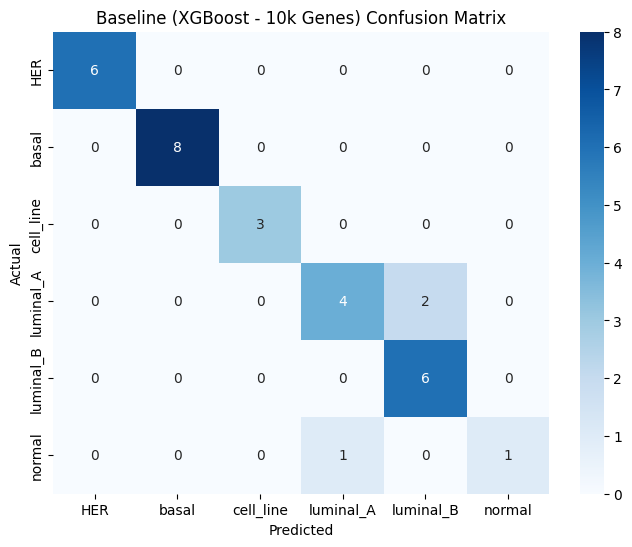

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize the Model (Optimized for 10k Features + GPU)
model_xgb = XGBClassifier(
    n_estimators=500,        # Increased: More trees needed to cover 10k features
    max_depth=4,             # Slightly deeper to find interactions in high-dim space
    learning_rate=0.05,      # Slower learning for better generalization

    # --- GPU Acceleration ---
    tree_method='hist',      # 'hist' is faster and required for GPU support in modern XGBoost
    device='cuda',           # Explicitly use the T4 GPU

    # --- Regularization (CRITICAL for 10k features) ---
    colsample_bytree=0.1,    # Only check 10% of genes per tree (reduces noise)
    subsample=0.8,           # Use 80% of patients per tree
    reg_alpha=0.5,           # L1 Regularization (Lasso) - helps select features
    reg_lambda=1.0,          # L2 Regularization (Ridge)

    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# 2. Train on the "Scaled" data
# Note: X_train_scaled has 10,000 columns now
print(f"Training XGBoost Baseline on {X_train_scaled.shape[1]} features (GPU)...")
model_xgb.fit(X_train_scaled, y_train)

# 3. Predict
y_pred_xgb = model_xgb.predict(X_test_scaled)

# 4. Evaluation Metrics
acc = accuracy_score(y_test, y_pred_xgb)
print(f"\n✅ Baseline Accuracy (10k features): {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# 5. Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Baseline (XGBoost - 10k Genes) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

✅ XGBoost Precision & Recall Report:

              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      1.00      1.00         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       0.80      0.67      0.73         6
   luminal_B       0.75      1.00      0.86         6
      normal       1.00      0.50      0.67         2

    accuracy                           0.90        31
   macro avg       0.92      0.86      0.88        31
weighted avg       0.91      0.90      0.90        31



/tmp/ipython-input-3322603567.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


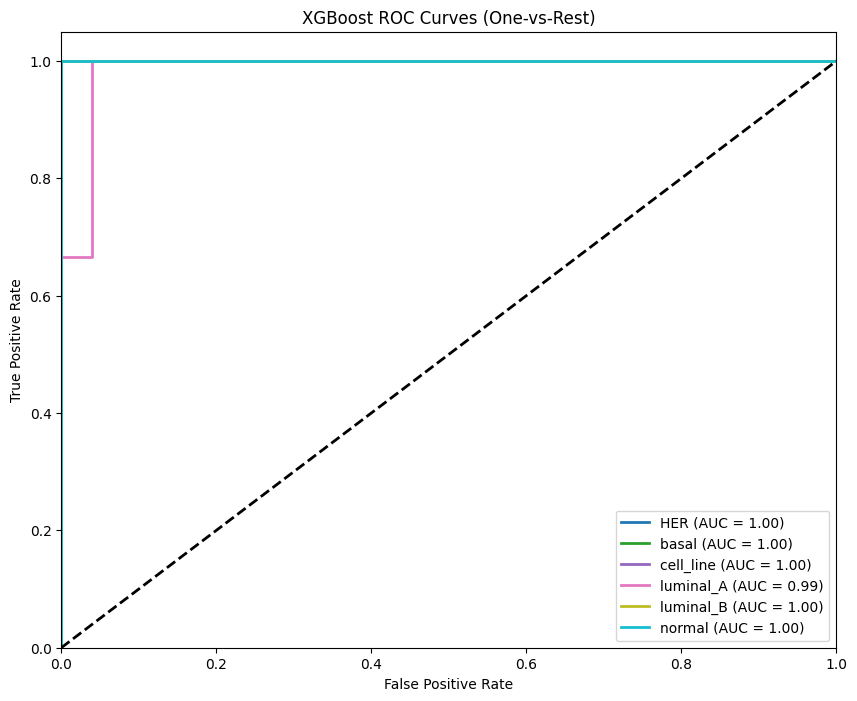

In [ ]:
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Get Probabilities & Binarize Labels ---
y_probs = model_xgb.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# --- 2. Print Precision/Recall Values (Text Report) ---
print("✅ XGBoost Precision & Recall Report:\n")
print(classification_report(y_test, model_xgb.predict(X_test_scaled), target_names=le.classes_))

# --- 3. Plot ROC Curve ---
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors(i), lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()